# 12 · Random Forest + Spatial Opportunity Detection

Este es el notebook principal del proyecto y el que hoy resume mejor el caso de uso final: estimar precio de publicación y detectar oportunidades inmobiliarias a partir de residuos espaciales.

El nombre del archivo se conserva por continuidad histórica, pero en esta versión operativa **no se aplica kriging sobre residuos**. Al trabajar con un volumen grande de datos, se optó por priorizar un pipeline más estable, rápido y fácil de reproducir usando un `Random Forest` fuerte como predictor base y un módulo espacial separado para el diagnóstico de oportunidades.

En este notebook se puede ver:
- cómo se cargan y preparan los splits principales
- cómo se entrena y evalúa el predictor tabular de referencia
- qué variables están empujando más la predicción
- cómo se construye el detector OOF de oportunidades
- y cómo se exploran esas oportunidades en mapas interactivos


## Hipótesis del enfoque

- Un `Random Forest` bien ajustado captura gran parte de la señal no lineal del precio de publicación.
- En esta escala de datos, conviene separar predicción y análisis espacial en lugar de sumar kriging residual dentro del predictor principal.
- Los residuos OOF permiten pasar de un problema de forecasting a una búsqueda de propiedades potencialmente subvaluadas.
- El contexto espacial local se puede reinyectar después, mediante `ZTest`, `LISA` y vecindarios `KNHS`, para priorizar oportunidades más convincentes.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
from pathlib import Path
import sys
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.rfrkModel import RegressionKrigingModel
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import generar_grid_predicciones,MapaPrecio,ZTestMapVisualizer,CombinedZLisaMapVisualizer
from ml_core import load_model_config, save_model_config
from ml_core.outlierAnalysis.oof import (
    detect_outliers_oof,
    load_active_processed_geodata,
)

from ml_core.preprocessing.knhs import KNHSSchema, KNHSWeightSpec
from ml_core.outlierAnalysis.oof import detect_outliers_oof
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "12_rf_kriging"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## Datos y configuración

In [3]:
DATA_PATH = PROJECT_ROOT / "data" / "splits"

train_raw = pd.read_csv(DATA_PATH / "arg_venta_data_train.csv")
gdf_train = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
gdf_test = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")
gdf_val = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)



target_col = "log_precio"   
coord_cols = ["longitud", "latitud"]
feature_cols = [
    'area_m2_cubierta',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num',
    'disposicion_Frente',
    'disposicion_Contrafrente',
    'disposicion_Lateral',
    'dist_subte',
    'dist_universidad',
    'dist_hospital',
    'dist_est_educativo',
    'dist_espacio_verde',
    'dist_areas_programaticas',
    'dist_avenida_rivadavia',
    "n_robos_1000m",
    "n_universidades_1000m",
    "pozo",
    "velocidad_ventas_1000m_90d"
]



In [4]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()

## Entrenamiento

In [5]:
rf_params = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 3,
    "max_features": "log2",
}

kriging_params = {
    "n_closest_points": 7,
    "variogram_model": "linear",
    "pseudo_inv": True,
    "pseudo_inv_type": "pinvh",
}

model = RegressionKrigingModel(rf_params=rf_params, kriging_params=kriging_params, use_kriging=False)
model.fit(X_train, y_train, coords_train)
model


In [6]:


config_path = Path("notebooks/cache/rfrk_best_config.json")
saved_config = load_model_config(config_path)

if saved_config is None:
    model = RegressionKrigingModel(
        rf_params=rf_params,
        kriging_params=kriging_params,
        use_kriging=False,
    )
    model.tune_hyperparameters(X_val, y_val.values.ravel(), coords_val)

    save_model_config(
        model,
        config_path,
        extra={"target": target_col, "features": feature_cols},
    )

    saved_config = load_model_config(config_path)

rf_params = saved_config.get("rf_params", {})
kriging_params = saved_config.get("kriging_params", {})

best_config = {"RegressionKriging_params": rf_params, "kriging_params": kriging_params, "selected_k": getattr(model, "kriging_params_", {}).get("n_closest_points", None)}
best_config


{'RegressionKriging_params': {'n_estimators': 500,
  'max_depth': None,
  'min_samples_leaf': 1,
  'max_features': 0.5,
  'bootstrap': True,
  'min_samples_split': 2},
 'kriging_params': {'n_closest_points': 7,
  'variogram_model': 'linear',
  'pseudo_inv': True,
  'pseudo_inv_type': 'pinvh'},
 'selected_k': None}

## Tuning del predictor base

En esta versión el tuning se concentra en el bosque, ya que el flujo principal del notebook usa `use_kriging=False`. La parte espacial aparece después como capa de diagnóstico sobre residuos OOF, no como componente interno del estimador de referencia.


## Evaluación global

In [7]:
rf_params = best_config["RegressionKriging_params"]
kriging_params = best_config["kriging_params"]
model = RegressionKrigingModel(rf_params=rf_params, kriging_params=kriging_params, use_kriging=False)
model.fit(X_train, y_train, coords_train)
model

y_pred_log = model.predict(
    X_test,
    coords_test
)

# revertir log
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

metrics = regression_metrics(
    y_true,
    y_pred
)

metrics

{'rmse': 32716.445948410725,
 'mae': 14937.9041600933,
 'r2': 0.9387543697017163,
 'bias': 3075.5938841126363,
 'median_abs_error': 6608.338042464864,
 'mape': 9.071972697495244}

## Visualización


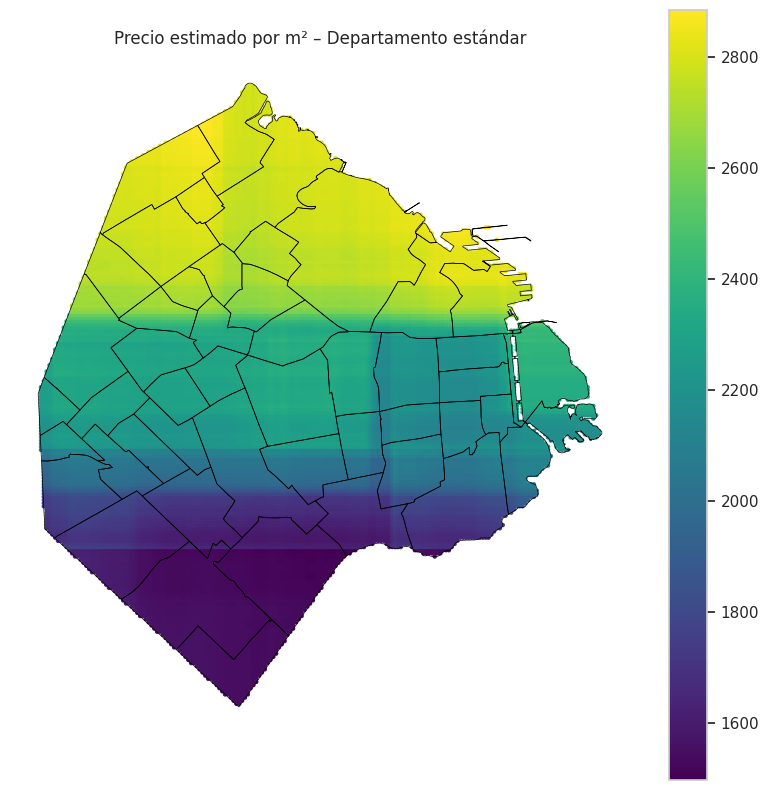

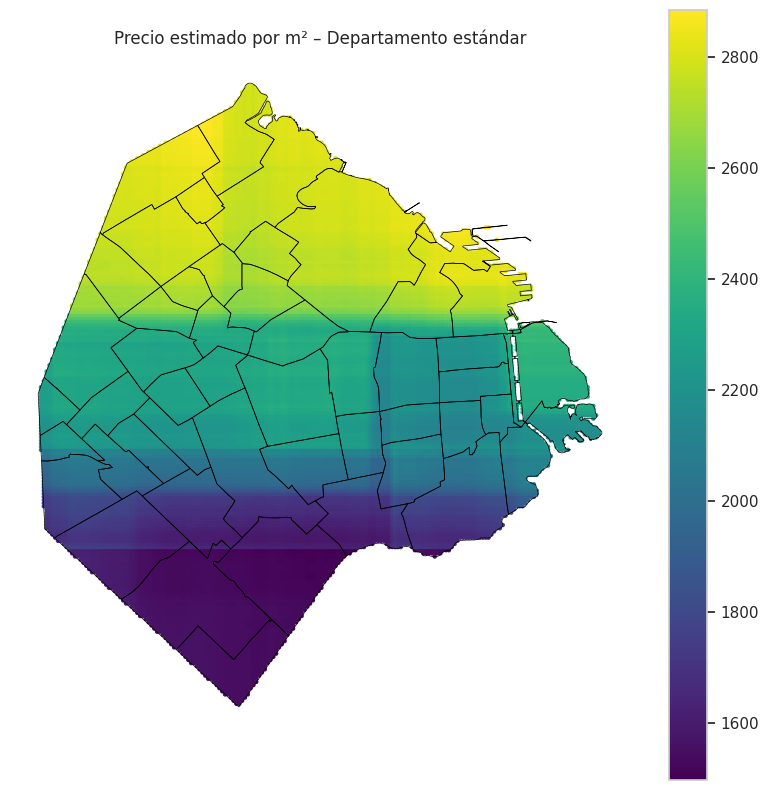

In [8]:
barrios_path = PROJECT_ROOT / 'GeoData' / 'barrios.geojson'

df_grid, barrios, std = generar_grid_predicciones(
    model,
    gdf_val,
    feature_cols
)

mapa = MapaPrecio(df_grid, barrios)

mapa.plot()

#mapa.save("mapa_modelo_lgwr.png")

#mapa.save("mapa_modelo_lgwr.pdf")



## Interpretación del Random Forest

Notamos que evidentemente el area cubierta parece tener la mayor importancia al momento de predecir el precio final, seguido por otras variables influyentes como la antiguedad y los ambientes.
Sorprende quizá que las expensas tengan tanta importancia, la explciación podría deberse a que da un fuerte indicio sobre las amenities que pueden tener los departamentos.

Luego observamos una gran importancia en features espaciales como la distancia al hospital mas cercano, la distancia al establecimiento educativo más cercano y a la avenida rivadavia. Esto podría indicar el fuerte apollo que toma en random forest (y en general los modelos tabulares) sobre las features espaciales para aprender esta codependencia espacial del problema subyacente.


In [9]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_(),
}).sort_values("importance", ascending=False)
feature_importance

,feature,importance
0,area_m2_cubierta,0.545162
3,antiguedad,0.211871
2,ambientes,0.105674
4,expensas,0.089782
13,dist_hospital,0.082974
17,dist_avenida_rivadavia,0.057156
14,dist_est_educativo,0.052558
1,area_m2_descubierta,0.045361
12,dist_universidad,0.042023
18,n_robos_1000m,0.041170


## Detección de oportunidades

A partir del predictor base, el siguiente paso es transformar errores de predicción en una señal operativa. Para eso se calculan residuos **out-of-fold**: en cada fold, el modelo entrena sin ver ese subconjunto y luego predice sobre él.

Ese esquema evita medir oportunidades sobre datos que el modelo ya usó para ajustarse y hace que el residuo sea más creíble como alerta de mercado.

Luego, sobre esos residuos OOF:
- se buscan valores atípicamente bajos con `ZTest`
- se agrega contexto espacial local con `LISA`
- y se usa un vecindario `KNHS` para mezclar cercanía geográfica y comparabilidad entre propiedades


In [10]:
from ml_core.preprocessing.knhs import KNHSSchema, KNHSWeightSpec
from ml_core.outlierAnalysis.oof import (
    detect_outliers_oof,
    load_active_processed_geodata,
)

rf_params = best_config["RegressionKriging_params"]
kriging_params = best_config["kriging_params"]

def build_rfrk_model():
    return RegressionKrigingModel(
        rf_params=rf_params,
        kriging_params=kriging_params,
        use_kriging=False,
    )

DATA_PATH = PROJECT_ROOT / "data" / "processed"

gdf_all = load_active_processed_geodata(
    data_path=DATA_PATH / "arg_venta_data_processed.csv",
    feature_cols=feature_cols,
    target_col=target_col,
    coord_cols=coord_cols,
    extra_cols=["idx", "url", "precio", "area_m2_total"],
)

X_all = gdf_all[feature_cols]
y_all = gdf_all[target_col]
coords_all = gdf_all[coord_cols].to_numpy()

knhs_schema = KNHSSchema(
    lat_col="lat_deg",
    lon_col="lon_deg",
    similarity_feature_cols=[
        "area_m2_cubierta",
        "area_m2_descubierta",
        "ambientes",
        "antiguedad",
        "expensas",
    ],
)

base_weights = {
    "w_area_m2_cubierta": 0.45,
    "w_area_m2_descubierta": 0.05,
    "w_ambientes": 0.15,
    "w_antiguedad": 0.25,
    "w_expensas": 0.10,
}

similarity_weights = pd.DataFrame(
    {col: np.full(len(X_all), value) for col, value in base_weights.items()},
    index=X_all.index,
)

knhs_weight_spec = KNHSWeightSpec(
    schema=knhs_schema,
    k=16,
    radius_km=2.0,
    feature_distance_mode="local_weighted",
    lambda_distance=0.5,
    bandwidth_mode="adaptive",
    row_standardize=True,
    similarity_weights=similarity_weights,
    similarity_weight_cols=list(similarity_weights.columns),
)

results_by_method, residuals_oof = detect_outliers_oof(
    model_factory=build_rfrk_model,
    X=X_all,
    y=y_all,
    gdf=gdf_all,
    coords=coords_all,
    output_dir=OUTPUT_DIR / "outliers_oof",
    methods=["ztest", "combined_z_lisa"],
    k_neighbors=16,
    n_splits=5,
    knhs_weight_spec=knhs_weight_spec,
)



Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5


## Mapa de Residuos

Graficamos un mapa con los residuos para observar las zonas con más error de predicción.

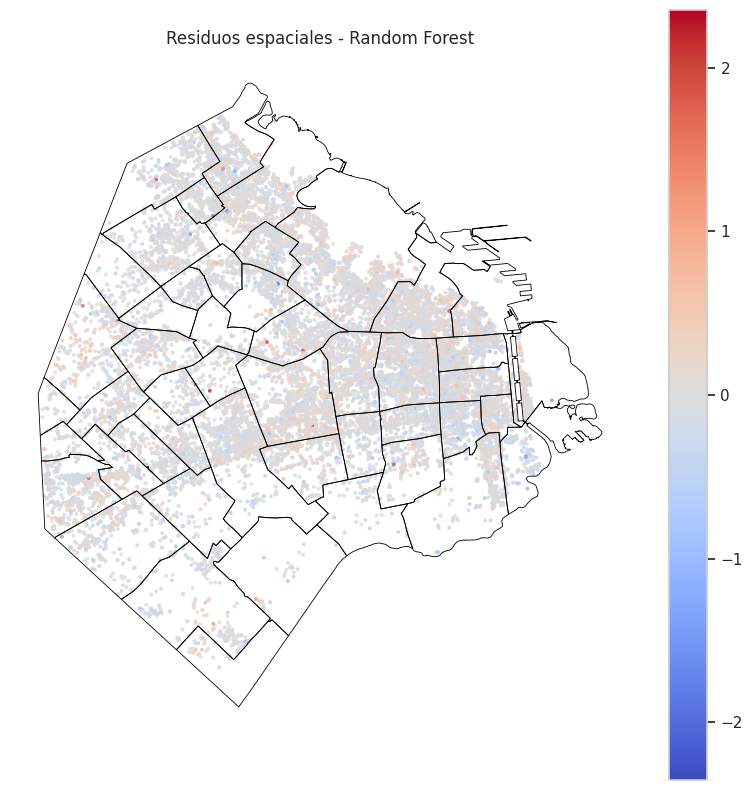

In [11]:


import geopandas as gpd
from ml_core.visualization.mapper import plot_residuals_map
gdf_res = gdf_all.copy()
gdf_res["residual"] = residuals_oof

fig, ax = plot_residuals_map(
    gdf=gdf_res,
    residual_col="residual",
    boundary_path=barrios_path,
    title="Residuos espaciales - Random Forest",
)


## Mapa interactivo de oportunidades (`ztest`)

Visualización de todos los avisos activos en CABA. El ranking sale del `p-value` del `ztest`, calculado sobre un vecindario `KNHS` que mezcla cercanía geográfica y similitud entre propiedades.


In [12]:
from IPython.display import IFrame, display

z_test_visualizer = ZTestMapVisualizer(
    gdf_all=gdf_all,
    results_df=results_by_method["ztest"],
    barrios_path=PROJECT_ROOT / "GeoData" / "barrios.geojson",
    filter_config={
        "precio": {"kind": "numeric", "label": "Precio"},
        "ambientes": {"kind": "numeric", "label": "Ambientes"},
        "area_m2_cubierta": {"kind": "numeric", "label": "Metros cuadrados"},
        "is_significant_outlier": {
            "kind": "boolean",
            "label": "Atípico (p ≤ 0.05)",
            "boolean_labels": {
                "all": "Todos",
                "true": "Solo atípicos",
                "false": "Solo no atípicos",
            },
        },
        "pozo": {
            "kind": "boolean",
            "label": "En pozo",
            "boolean_labels": {
                "all": "Todos",
                "true": "Solo en pozo",
                "false": "Solo no en pozo",
            },
        },
    },
    popup_fields=[
        "precio",
        "precio_estimado",
        "area_m2_cubierta",
        "area_m2_descubierta",
        "ambientes",
        "pozo",
        "p_value_z",
        "residuo",
        "url",
    ],
)

z_test_map = z_test_visualizer.build_map()
z_test_map_path = OUTPUT_DIR / "outliers_oof" / "z_test_interactive_map.html"
z_test_visualizer.save_map(z_test_map_path)
display(IFrame(src=str(z_test_map_path.relative_to(PROJECT_ROOT)), width="100%", height=700))


## Mapa interactivo de oportunidades (`combined_z_lisa`)

Visualización de todos los avisos activos en CABA. Mantiene el `p-value` del `ztest` como señal principal y suma el cuadrante y `p-value` de LISA como contexto espacial, sobre el mismo vecindario `KNHS`.


In [13]:
from IPython.display import IFrame, display

combined_z_lisa_visualizer = CombinedZLisaMapVisualizer(
    gdf_all=gdf_all,
    results_df=results_by_method["combined_z_lisa"],
    barrios_path=PROJECT_ROOT / "GeoData" / "barrios.geojson",
    filter_config={
        "precio": {"kind": "numeric", "label": "Precio"},
        "ambientes": {"kind": "numeric", "label": "Ambientes"},
        "area_m2_cubierta": {"kind": "numeric", "label": "Metros cuadrados"},
        "pozo": {
            "kind": "boolean",
            "label": "En pozo",
            "boolean_labels": {
                "all": "Todos",
                "true": "Solo en pozo",
                "false": "Solo no en pozo",
            },
        },
        "quadrant": {
            "kind": "categorical",
            "label": "Cuadrante LISA",
            "categories": {
                "HH": "Alto-Alto",
                "LL": "Bajo-Bajo",
                "HL": "Alto-Bajo",
                "LH": "Bajo-Alto"},
                }
    },
    popup_fields=[
        "precio",
        "precio_estimado",
        "area_m2_cubierta",
        "area_m2_descubierta",
        "ambientes",
        "pozo",
        "p_value_z",
        "residuo",
        "url",
    ],
)
combined_z_lisa_map = combined_z_lisa_visualizer.build_map()
combined_z_lisa_map_path = OUTPUT_DIR / "outliers_oof" / "combined_z_lisa_interactive_map.html"
combined_z_lisa_visualizer.save_map(combined_z_lisa_map_path)
display(IFrame(src=str(combined_z_lisa_map_path.relative_to(PROJECT_ROOT)), width="100%", height=700))
